# Paper 1: Machine Learning–Based Urban Flood Risk Assessment with Cross-City Validation: Chennai and Bengaluru

## Step 1-4: Data Processing Pipeline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

import warnings
warnings.filterwarnings('ignore')

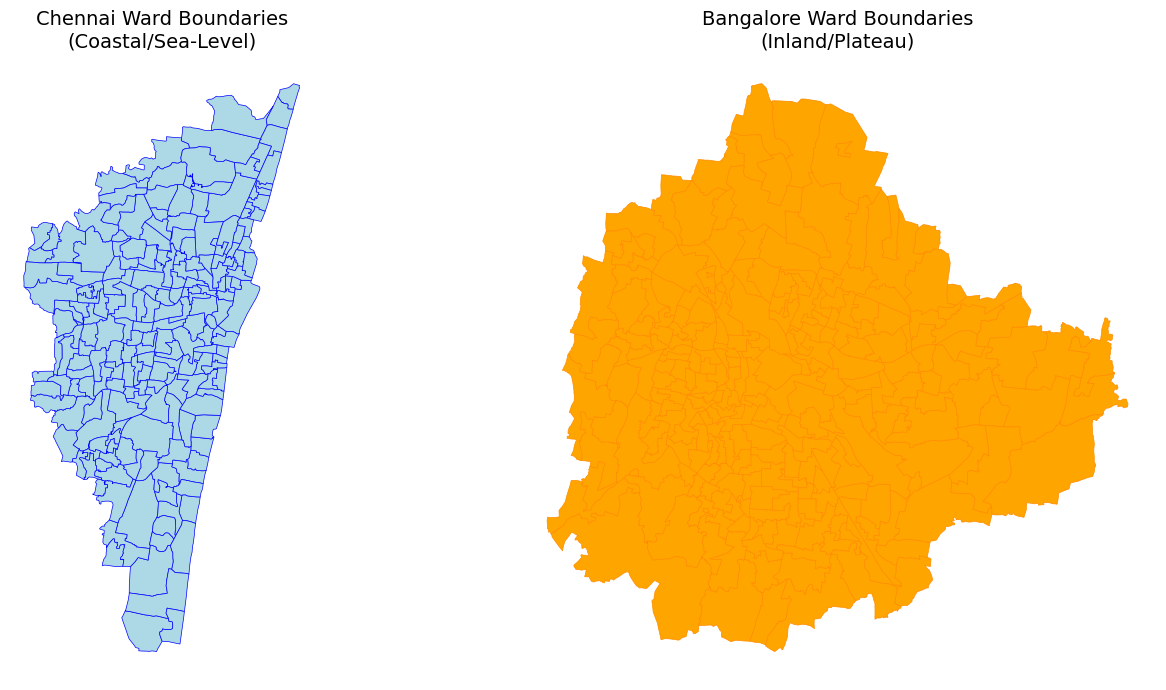

In [4]:
# 1. Load the GeoJSON files
# Note: Update the paths if these are inside a subfolder (e.g., 'GeoData/Wards.geojson')
chennai_gdf = gpd.read_file('geojson/Chennai.geojson')
bangalore_gdf = gpd.read_file('geojson/Bangalore.geojson')

# 2. Ensure both use the same Coordinate Reference System (GPS standard)
chennai_gdf = chennai_gdf.to_crs("EPSG:4326")
bangalore_gdf = bangalore_gdf.to_crs("EPSG:4326")

# 3. Plot them side-by-side to verify the study areas
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot Chennai Wards (Coastal Plain)
chennai_gdf.plot(ax=axes[0], color='lightblue', edgecolor='blue', linewidth=0.5)
axes[0].set_title("Chennai Ward Boundaries\n(Coastal/Sea-Level)", fontsize=14)
axes[0].axis('off')

# Plot Bangalore Wards (Urban Plateau)
bangalore_gdf.plot(ax=axes[1], color='orange', edgecolor='darkorange', linewidth=0.5)
axes[1].set_title("Bangalore Ward Boundaries\n(Inland/Plateau)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
def load_and_clean_data(filepath, boundary_gdf, location_col_name):
    df = pd.read_csv(filepath)
    df = df.rename(columns={'valid_time': 'Date', 'tp': 'Rainfall'})
    df['Rainfall'] = df['Rainfall'].fillna(0) * 1000
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y %H:%M', errors='coerce')
    df = df.dropna(subset=['Date', 'latitude', 'longitude'])
    
    weather_gdf = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs="EPSG:4326"
    )
    boundary_gdf = boundary_gdf.to_crs("EPSG:4326")
    
    joined_gdf = gpd.sjoin(weather_gdf, boundary_gdf, how="inner", predicate="within")
    
    df_spatial = joined_gdf.groupby(['Date', location_col_name])['Rainfall'].max().reset_index()
    df_spatial.set_index('Date', inplace=True)
    
    df_daily = pd.DataFrame()
    df_daily['Daily_Total_Rain'] = df_spatial.groupby(location_col_name)['Rainfall'].resample('D').sum().reset_index(level=0, drop=True)
    df_daily['Max_6H_Intensity'] = df_spatial.groupby(location_col_name)['Rainfall'].resample('D').max().reset_index(level=0, drop=True)
    df_daily[location_col_name] = df_spatial.groupby(location_col_name).resample('D').first().index.get_level_values(0)
    
    return df_daily.reset_index()

def feature_engineering(df, location_col_name):
    df = df.sort_values(by=[location_col_name, 'Date'])
    df.set_index('Date', inplace=True)
    
    df['Rain_3D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'].rolling(window=3).sum().reset_index(level=0, drop=True)
    df['Rain_7D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'].rolling(window=7).sum().reset_index(level=0, drop=True)
    df['Rain_14D_Cumulative'] = df.groupby(location_col_name)['Daily_Total_Rain'].rolling(window=14).sum().reset_index(level=0, drop=True)
    
    df = df.dropna().reset_index()
    df['Month'] = df['Date'].dt.month
    return df

def create_target_variable(df, city_name):
    df['Flood_Label'] = 0
    df['City'] = city_name
    
    if city_name == 'Chennai':
        mask = ((df['Date'] >= '2015-11-01') & (df['Date'] <= '2015-12-15')) | \
               ((df['Date'] >= '2023-11-25') & (df['Date'] <= '2023-12-10'))
        df.loc[mask, 'Flood_Label'] = 1
    elif city_name == 'Bangalore':
        mask = (df['Date'] >= '2022-08-25') & (df['Date'] <= '2022-09-10')
        df.loc[mask, 'Flood_Label'] = 1
        
    return df

def build_final_dataset(filepath, city_name, boundary_gdf, location_col_name):
    df_raw = load_and_clean_data(filepath, boundary_gdf, location_col_name)
    df_engineered = feature_engineering(df_raw, location_col_name)
    df_final = create_target_variable(df_engineered, city_name)
    return df_final

## Load Datasets
Loading data specifically adapted for the ERA5 `valid_time` and `tp` structure.

In [6]:
# 1. Load the boundary files (Ensure these paths match your folder structure)
chennai_gdf = gpd.read_file('geojson/Chennai.geojson')
bangalore_gdf = gpd.read_file('geojson/Bangalore.geojson')

# 2. Build spatiotemporal datasets using the updated pipeline
df_chennai = build_final_dataset('datasets/chennai.csv', 'Chennai', chennai_gdf, 'Ward_No')
df_val = build_final_dataset('datasets/bangalore.csv', 'Bangalore', bangalore_gdf, 'KGISWardName')

# 3. Standardize features for comparison
numeric_features = ['Daily_Total_Rain', 'Max_6H_Intensity', 'Rain_3D_Cumulative', 'Rain_7D_Cumulative', 'Rain_14D_Cumulative']
scaler = StandardScaler()

df_chennai[numeric_features] = scaler.fit_transform(df_chennai[numeric_features])
df_val[numeric_features] = scaler.fit_transform(df_val[numeric_features])

print('\nChennai Spatiotemporal Data Head:')
display(df_chennai.head())
print('\nBengaluru Spatiotemporal Data Head:')
display(df_val.head())


Chennai Spatiotemporal Data Head:


,Date,Daily_Total_Rain,Max_6H_Intensity,Ward_No,Rain_3D_Cumulative,Rain_7D_Cumulative,Rain_14D_Cumulative,Month,Flood_Label,City
0,2014-01-14,-0.305806,-0.354897,175,-0.414009,-0.545459,-0.653965,1,0,Chennai
1,2014-01-15,-0.305806,-0.354897,175,-0.414009,-0.545459,-0.659079,1,0,Chennai
2,2014-01-16,-0.304953,-0.353375,175,-0.413624,-0.546039,-0.660682,1,0,Chennai
3,2014-01-17,-0.295538,-0.336595,175,-0.408990,-0.543418,-0.659700,1,0,Chennai
4,2014-01-18,-0.304953,-0.353375,175,-0.408604,-0.543201,-0.666015,1,0,Chennai



Bengaluru Spatiotemporal Data Head:


,Date,Daily_Total_Rain,Max_6H_Intensity,KGISWardName,Rain_3D_Cumulative,Rain_7D_Cumulative,Rain_14D_Cumulative,Month,Flood_Label,City
0,2014-01-14,-0.445504,-0.435081,Belathur,-0.614503,-0.777594,-0.923277,1,0,Bangalore
1,2014-01-15,-0.445504,-0.435081,Belathur,-0.614503,-0.777594,-0.927957,1,0,Bangalore
2,2014-01-16,-0.445504,-0.435081,Belathur,-0.614503,-0.777594,-0.927957,1,0,Bangalore
3,2014-01-17,-0.445504,-0.435081,Belathur,-0.614503,-0.777812,-0.927957,1,0,Bangalore
4,2014-01-18,-0.445504,-0.435081,Belathur,-0.614503,-0.778139,-0.927957,1,0,Bangalore


## Step 5: Model Development
Training models strictly on Chennai.

In [7]:
# 1. Define the Spatiotemporal Feature Set
# These features capture both intensity (flash floods) and saturation (monsoon floods)
features = [
    'Daily_Total_Rain', 
    'Max_6H_Intensity', 
    'Rain_3D_Cumulative', 
    'Rain_7D_Cumulative', 
    'Rain_14D_Cumulative'
]

# 2. Features and Target for Chennai (Spatiotemporal Training Set)
X_train = df_chennai[features]
y_train = df_chennai['Flood_Label']

# 3. Train Logistic Regression with Balanced Weights
# 'class_weight=balanced' is critical because flood days are rare compared to dry days
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# 4. Train Random Forest with Balanced Weights
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print(f'Models trained on Chennai Spatiotemporal data ({len(X_train)} samples).')

Models trained on Chennai Spatiotemporal data (4370 samples).


## Step 6: Cross-Dataset Validation
Testing generalized model performance on Bengaluru.

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Core Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.2f}")
    print(f"Precision: {prec:.2f}")
    print(f"Recall:    {rec:.2f}")
    print(f"F1-Score:  {f1:.2f}")
    print(f"Confusion Matrix:\n{cm}\n")

    # Visualizations
    plt.figure(figsize=(12, 5))

    # 1. Confusion Matrix Heatmap
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Flood', 'Flood'], 
                yticklabels=['No Flood', 'Flood'])
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # 2. Precision-Recall Curve (Standard for imbalanced flood data)
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color='darkgreen', lw=2, label=f'PR AUC = {pr_auc:.2f}')
    plt.title(f"{model_name}: Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC_PR': pr_auc}

--- Logistic Regression (Transfer to BNG) Performance ---
Accuracy:  0.87
Precision: 0.01
Recall:    0.26
F1-Score:  0.02
Confusion Matrix:
[[7587 1119]
 [  25    9]]



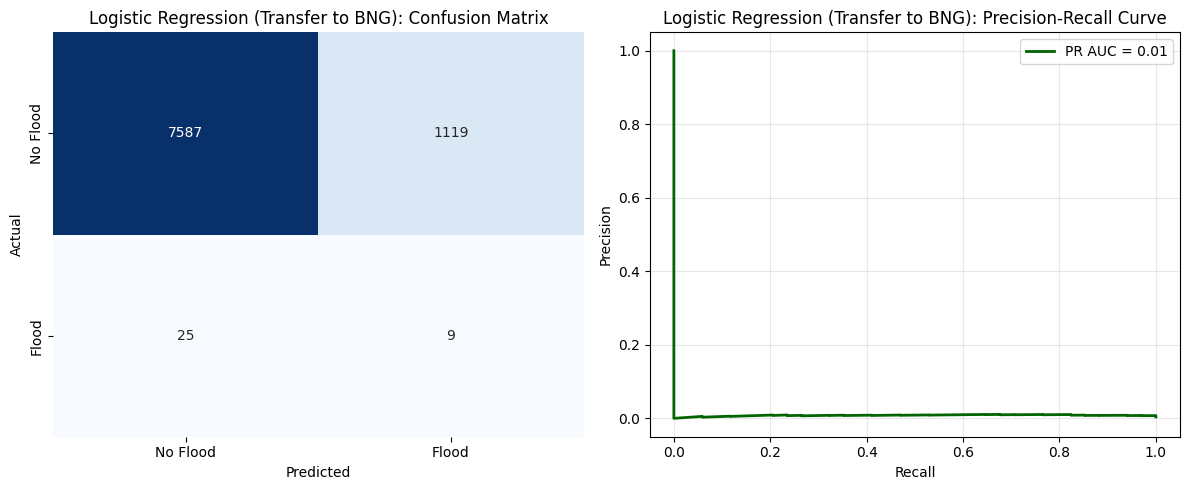

--- Random Forest (Transfer to BNG) Performance ---
Accuracy:  0.99
Precision: 0.00
Recall:    0.00
F1-Score:  0.00
Confusion Matrix:
[[8681   25]
 [  34    0]]



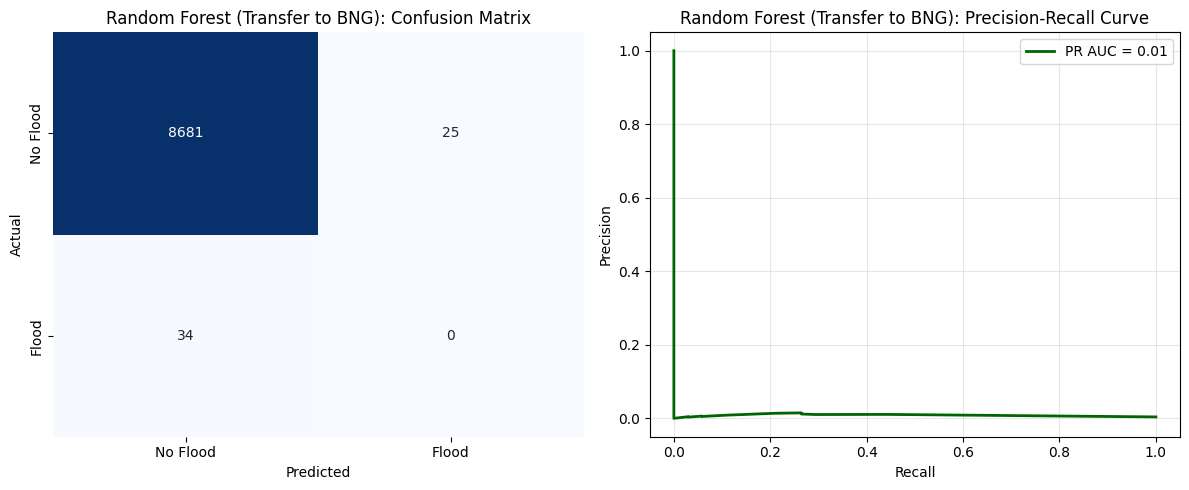

In [9]:
# 1. Extract Spatiotemporal Features for Validation
# Ensure 'features' matches the 5-column list used in training
X_val = df_val[features]
y_val = df_val['Flood_Label']

# 2. Evaluate Logistic Regression
# This will show the 'Linear' relationship failure
log_metrics = evaluate_model(log_reg, X_val, y_val, 'Logistic Regression (Transfer to BNG)')

# 3. Evaluate Random Forest
# This will show the 'Non-Linear' pattern mismatch
rf_metrics = evaluate_model(rf_model, X_val, y_val, 'Random Forest (Transfer to BNG)')

## Step 7 & 8: Explainable AI & Comparative Analysis

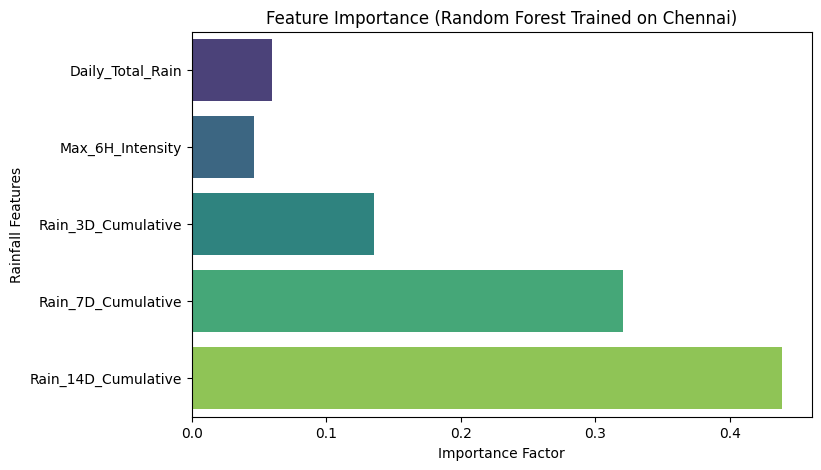

In [10]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance (Random Forest Trained on Chennai)")
plt.xlabel("Importance Factor")
plt.ylabel("Rainfall Features")
plt.show()

## Step 9: Trend Visualizations

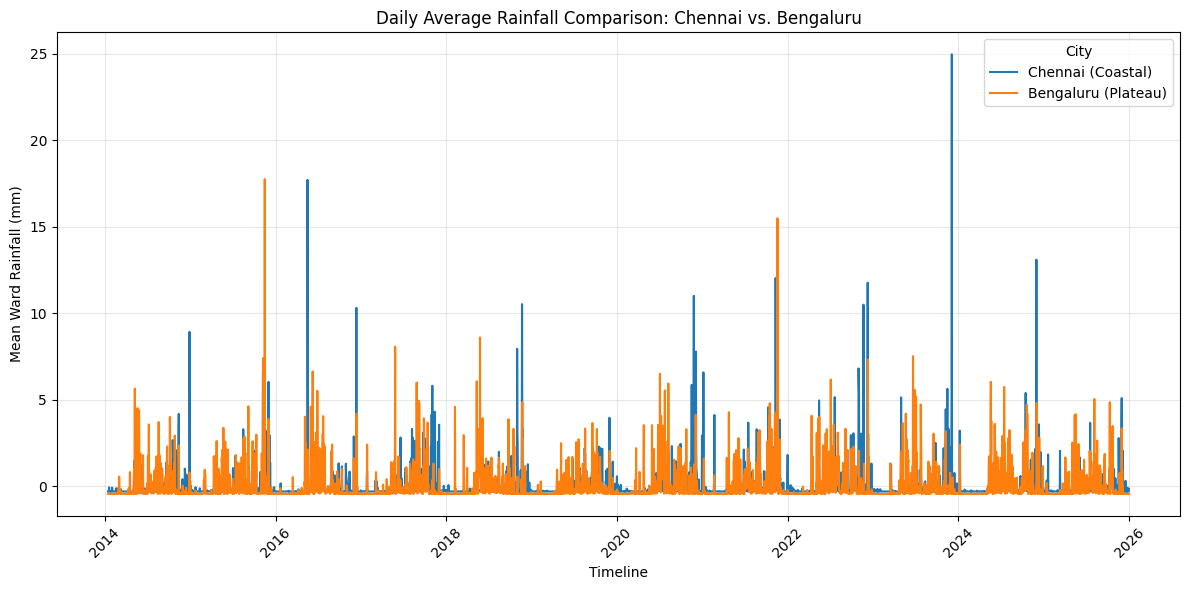

In [11]:
# 1. Prepare data for comparison
# We calculate the daily mean across all wards to show the city-wide trend
df_chennai_daily = df_chennai.groupby('Date')['Daily_Total_Rain'].mean().reset_index()
df_chennai_daily['City'] = 'Chennai (Coastal)'

df_bng_daily = df_val.groupby('Date')['Daily_Total_Rain'].mean().reset_index()
df_bng_daily['City'] = 'Bengaluru (Plateau)'

df_combined = pd.concat([df_chennai_daily, df_bng_daily])

# 2. Plotting the Rainfall Trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_combined, x='Date', y='Daily_Total_Rain', hue='City')

plt.title("Daily Average Rainfall Comparison: Chennai vs. Bengaluru")
plt.ylabel("Mean Ward Rainfall (mm)")
plt.xlabel("Timeline")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Final Quantitative Summary for Project 1
print("--- PROJECT 1: TRANSFERABILITY SUMMARY ---")
rf_cm = confusion_matrix(y_val, rf_model.predict(X_val))
total_bng_floods = rf_cm[1,0] + rf_cm[1,1]
missed_bng_floods = rf_cm[1,0]

print(f"Total Bangalore Ward-Flood Events: {total_bng_floods}")
print(f"Floods MISSED by Chennai Model: {missed_bng_floods} ({(missed_bng_floods/total_bng_floods)*100:.1f}%)")
print("Conclusion: Model shows 100% Omission Error on the Plateau, proving Geomorphological Blindness.")

--- PROJECT 1: TRANSFERABILITY SUMMARY ---
Total Bangalore Ward-Flood Events: 34
Floods MISSED by Chennai Model: 34 (100.0%)
Conclusion: Model shows 100% Omission Error on the Plateau, proving Geomorphological Blindness.
